# Self-Attention: Building the Foundation of Transformers

## Understanding Attention Through Implementation

In this notebook, you'll build self-attention from scratch to understand the mechanism that revolutionized natural language processing. Rather than treating attention as a black box, you'll see exactly how it computes relationships between words, why it's so powerful, and how it learns to focus on relevant context.

Self-attention is the core innovation that enables models like BERT, GPT, and other transformers to understand language. By the end of this notebook, you'll have implemented the same attention mechanism used in these state-of-the-art models, working through simple examples to build deep intuition about how and why it works.

Let's demystify attention by coding each component step by step, visualizing the computations, and seeing how different patterns emerge from the learning process.

## 1 - Data Preparation

### 1.1 Introduction

Before you can train any language model, you need to convert raw text into a numerical format that the model can understand. This fundamental step transforms human-readable text into the mathematical representations that neural networks require.

You'll start by preparing a **toy dataset**: just a few simple sentences. This small scale lets you trace through every computation and truly understand what's happening inside the attention mechanism.

As part of this process, you'll build a vocabulary that includes:
- A **padding token** (`<pad>`) for making all sequences the same length in a batch
- An **unknown token** (`<unk>`) to handle any rare or out-of-vocabulary words the model might encounter

These special tokens are essential for handling real-world text where sequences vary in length and new words may appear during inference.

Let's begin!

In [1]:
import math
import os
import re
import urllib.request
from collections import Counter
from typing import Callable, Dict, List, Optional, Sequence

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

In [2]:
# 1. Tiny toy dataset
sentences = """
the dog chased the cat
the cat chased the mouse
the dog ran fast
the mouse ran fast
the cat lay down
"""

# Build vocab
tokens = sentences.split()
print(set(tokens))
vocab = ['<pad>', '<unk>'] + sorted(set(tokens))
word2idx = {w:i for i,w in enumerate(vocab)}
idx2word = {i:w for w,i in word2idx.items()}
print("Vocab:", vocab)

{'dog', 'mouse', 'down', 'lay', 'fast', 'chased', 'ran', 'cat', 'the'}
Vocab: ['<pad>', '<unk>', 'cat', 'chased', 'dog', 'down', 'fast', 'lay', 'mouse', 'ran', 'the']


### 1.2 The Tokenizer

A fundamental step in any NLP pipeline is **tokenization**. A tokenizer splits raw text into meaningful chunks (tokens)—typically words—that become the basic units your model processes. Since neural networks work with numbers, not text, the tokenizer also handles the crucial task of mapping these tokens to unique numerical IDs.

Below, you'll define a simple Python tokenizer as a class. This version uses regular expressions to extract whole words while normalizing the text by:
- Converting everything to lowercase for consistency
- Removing punctuation to focus on word meanings
- Splitting on whitespace and word boundaries

This clean, simplified approach is perfect for understanding attention mechanics without getting distracted by complex linguistic edge cases.

In [3]:
class SimpleTokenizer:
    """
    Splits on whitespace and lowercases, with optional regex for real word tokens.
    """
    def __init__(self):
        """
        Initializes the SimpleTokenizer instance.
        """
        pass

    def __call__(self, text):
        """
        Processes the input text into a list of lowercase word tokens.
        
        Args:
            text: The string to be tokenized.
            
        Returns:
            A list of strings containing the extracted tokens.
        """
        # Option 1: Basic split (uncomment to just split on spaces)
        # return text.lower().split()
        # Option 2: More robust - returns only word tokens (ignores punctuation)
        return re.findall(r'\b\w+\b', text.lower())

In [4]:
# Usage example:
tokenizer = SimpleTokenizer()
tokens = tokenizer("The Dog chased the Cat.")
print(tokens)  # Output: ['the', 'dog', 'chased', 'the', 'cat']

['the', 'dog', 'chased', 'the', 'cat']


### 1.3 Building the Vocabulary

Once you have a tokenizer that splits your sentences into individual words, the next step is to build a **vocabulary**—a list of all unique tokens that appear in your dataset.

This vocabulary is crucial because it links each word to a unique ID, which your model will use throughout training and inference. You'll also want to include two special tokens in your vocabulary: one for padding (`<pad>`) and one for unknown or out-of-vocabulary tokens (`<unk>`).

Below you'll find a function to create:
- the vocabulary list,
- a dictionary that maps each token to its unique index (**word2idx**),
- and a reverse mapping from indices to words (**idx2word**).

You can adjust the `min_freq` parameter to exclude rare words and keep your vocabulary more manageable.

In [5]:
def build_vocab(sentences, tokenizer, min_freq=1):
    """
    Constructs a vocabulary and mapping dictionaries from a collection of sentences.

    Args:
        sentences: A collection of strings to be processed.
        tokenizer: A callable object used to split sentences into individual tokens.
        min_freq: The minimum number of occurrences required for a token to be 
                  included in the vocabulary.

    Returns:
        vocab: A list of unique tokens including special padding and unknown markers.
        word2idx: A dictionary mapping each token string to its unique integer index.
        idx2word: A dictionary mapping each integer index back to its token string.
    """
    # Initialize a frequency counter for tokens
    counter = Counter()
    # Iterate through each sentence to update token counts
    for sent in sentences:
        # Generate tokens using the provided tokenizer and update the counter
        counter.update(tokenizer(sent))

    # Define the initial vocabulary with special tokens and filter by frequency
    vocab = ['<pad>', '<unk>'] + [w for w, c in counter.items() if c >= min_freq]

    # Map each unique word in the vocabulary to a specific integer index
    word2idx = {w: i for i, w in enumerate(vocab)}

    # Map each integer index back to its corresponding word
    idx2word = {i: w for i, w in enumerate(vocab)}

    # Provide the list of tokens and the bidirectional mapping dictionaries
    return vocab, word2idx, idx2word

In [6]:
# Using our sample sentences and tokenizer
sentences = [
    "the dog chased the cat",
    "the cat chased the mouse",
    "the dog ran fast",
    "the mouse ran fast",
    "the cat lay down"
]

tokenizer = SimpleTokenizer()                 # Define the tokenizer (splits into lowercase words)
vocab, word2idx, idx2word = build_vocab(sentences, tokenizer)  # Build vocab & mappings

print(vocab)

['<pad>', '<unk>', 'the', 'dog', 'chased', 'cat', 'mouse', 'ran', 'fast', 'lay', 'down']


In [7]:
word = 'dog'
id_word = word2idx[word]
print(f"ID for word = {word}: {id_word}")
print(f"Word for ID = {id_word}: {idx2word[id_word]}")

ID for word = dog: 3
Word for ID = 3: dog


### 1.4 Sliding Windows

Now that you have a list of tokenized and numericalized sentences, you need to organize your data into **(input, target)** pairs suitable for training a language model.

The most common approach for this is to use a **sliding window**: you select a fixed-size window of words as input, and train the model to predict the next word that follows the window. By moving this window across every sentence in your dataset, you generate many (input, target) examples for training.

This method helps your model learn the sequential structure of language, so it can anticipate what comes next given a context. For example:

| Step | Input                              | Target  |
|------|------------------------------------|---------|
|  1   | the, dog, chased, the              | cat     |
|  2   | dog, chased, the, cat              | quickly |

Now you'll implement this sliding window approach in code. This will prepare your input and target lists, ready for training your attention-based model.

In [8]:
tokenizer = SimpleTokenizer()
vocab, word2idx, idx2word = build_vocab(sentences, tokenizer)

# 2. Parameters
SEQ_LEN = 4   # Length of input sequence for each example

# 3. Convert sentences to token ID lists
encoded_sentences = []  # Will be a list of lists of token IDs
for sent in sentences:
    tokens = tokenizer(sent)  # Split sentence into tokens
    ids = [word2idx.get(tok, word2idx['<unk>']) for tok in tokens]  # Map tokens to IDs
    encoded_sentences.append(ids)

# 4. Create sliding window dataset (inputs, targets)
inputs = []
targets = []
for ids in encoded_sentences:
    # For each possible window in the sentence
    print(ids)
    for i in range(len(ids) - SEQ_LEN):
        window = ids[i:i+SEQ_LEN]        # Input: SEQ_LEN-token window
        target = ids[i+SEQ_LEN]          # Target: next token after the window
        inputs.append(window)
        targets.append(target)

# 5. Let's show the dataset as text for illustration
for inp, tgt in zip(inputs, targets):
    inp_words = [idx2word[i] for i in inp]
    tgt_word = idx2word[tgt]
    print(f"Input: {inp_words}  →  Target: {tgt_word}")

[2, 3, 4, 2, 5]
[2, 5, 4, 2, 6]
[2, 3, 7, 8]
[2, 6, 7, 8]
[2, 5, 9, 10]
Input: ['the', 'dog', 'chased', 'the']  →  Target: cat
Input: ['the', 'cat', 'chased', 'the']  →  Target: mouse


### 1.5 Turning the Data Into a PyTorch Dataset

Now that you’ve prepared your `inputs` and `targets` lists, it’s time to convert them into a format that PyTorch can use for training: a `Dataset`.

A PyTorch `Dataset` is a simple class structure that knows how to return an input–target pair given an index. This makes it easy to batch your data and feed it into a model, especially for larger sets of examples.

Below, you’ll see how to wrap your lists in a `Dataset`, and then use a `DataLoader` to shuffle and batch your data automatically during training.

In [9]:
class TinyDataset(Dataset):
    """
    A custom Dataset class for managing input-target pairs in a PyTorch-compatible format.

    Args:
        inputs: A list or array of input sequences/windows.
        targets: A list or array of target labels corresponding to the inputs.
    """
    def __init__(self, inputs, targets):
        """
        Initializes the dataset by converting raw data into tensors.

        Args:
            inputs: The input data sequences.
            targets: The target labels or word indices.
        """
        # Convert input windows to a long tensor for efficient indexing
        self.inputs = torch.tensor(inputs, dtype=torch.long)
        # Convert target indices to a long tensor
        self.targets = torch.tensor(targets, dtype=torch.long)

    def __len__(self):
        """
        Provides the total number of samples available in the dataset.

        Returns:
            An integer representing the total count of input samples.
        """
        # Return the total length of the input tensor
        return len(self.inputs)

    def __getitem__(self, idx):
        """
        Retrieves a specific sample and its corresponding target by index.

        Args:
            idx: The integer index of the desired sample.

        Returns:
            sample: The input tensor at the specified index.
            target: The target tensor at the specified index.
        """
        # Return the input-target pair as a tuple for the requested index
        return self.inputs[idx], self.targets[idx]

In [10]:
# Create an instance of your dataset
dataset = TinyDataset(inputs, targets)

# Create a DataLoader that will feed batches of data to your model during training.
# batch_size=4: each batch will contain 4 (input, target) pairs
# shuffle=True: randomize order each epoch to improve training
# num_workers=0: no extra processes for loading data (good for small datasets)
loader = DataLoader(dataset, batch_size=4, shuffle=True, num_workers=0)

## 2 - Manual Self-Attention

### 2.1 Introduction

Now you'll dig into the heart of what makes Transformers powerful: **self-attention**.

#### What is Self-Attention?

Self-attention is a mechanism that allows each word in a sequence to "look at" and "gather information from" every other word, including itself. Unlike traditional sequential models that process words one by one, self-attention computes relationships between all words simultaneously.

Think of it this way: when you read the sentence "The cat sat on the mat because it was tired," your brain automatically knows that "it" refers to "cat." Self-attention gives neural networks this same capability to understand relationships and dependencies between words, no matter how far apart they are.

#### The Self-Attention Algorithm

Here's how self-attention transforms a sequence:

```
Input: "The cat sat"
         ↓
   [Embeddings]
         ↓
   Q, K, V Projections
         ↓
   Attention Scores (Q × K^T)
         ↓
   Attention Weights (Softmax)
         ↓
   Weighted Sum (Weights × V)
         ↓
Output: Context-aware representations
```

#### The Core Components

Self-attention operates through three learned transformations of your input:

1. **Queries (Q)**: "What information am I looking for?"
   - Each word generates a query vector representing what it wants to know

2. **Keys (K)**: "What information do I contain?"
   - Each word generates a key vector advertising what information it has

3. **Values (V)**: "What information will I actually provide?"
   - Each word generates a value vector containing its actual contribution

#### The Attention Computation Flow

```
Step 1: Linear Projections
Input → W_Q → Queries
Input → W_K → Keys  
Input → W_V → Values

Step 2: Similarity Scores
Scores = Q × K^T / √d_k
(How relevant is each word to every other word?)

Step 3: Attention Weights  
Weights = Softmax(Scores)
(Convert scores to probabilities)

Step 4: Weighted Aggregation
Output = Weights × V
(Combine values based on attention weights)
```

#### Visual Example

Consider the sentence "The cat sat":

```
Attention Weight Matrix:
        The   cat   sat
The   [0.6   0.3   0.1]  ← "The" pays most attention to itself
cat   [0.2   0.7   0.1]  ← "cat" focuses mainly on itself  
sat   [0.1   0.3   0.6]  ← "sat" attends to "cat" and itself

Each row shows where that word "looks" for information
```

After training, these attention patterns become more sophisticated:
- "sat" might learn to strongly attend to "cat" (the subject)
- Articles like "the" might distribute attention more evenly
- Pronouns would learn to attend to their antecedents

#### Why Self-Attention is Powerful

1. **Parallel Processing**: Unlike RNNs, all positions are processed simultaneously
2. **Long-Range Dependencies**: Can directly connect distant words without sequential steps
3. **Interpretability**: Attention weights show what the model is "looking at"
4. **Flexibility**: Learns task-specific attention patterns automatically

Step by step, you'll implement each part of the self-attention formula—projections, dot products, scaling, softmax, and the final weighted sum—all by hand. This careful, explicit walkthrough will help you truly understand how self-attention works under the hood. Start slow here; later on, you'll see how these same ideas power much more complex, real-world NLP models!

In [11]:
class ManualSelfAttention(nn.Module):
    """
    A custom PyTorch module that implements a standard self-attention mechanism.
    
    Args:
        d: The dimensionality of the input and output features.
    """
    def __init__(self, d):
        """
        Initializes the linear layers for query, key, and value projections.

        Args:
            d: The dimensionality of the hidden state.
        """
        super().__init__()
        # Define the linear transformation for query vectors
        self.to_q = nn.Linear(d, d, bias=False)
        # Define the linear transformation for key vectors
        self.to_k = nn.Linear(d, d, bias=False)
        # Define the linear transformation for value vectors
        self.to_v = nn.Linear(d, d, bias=False)

    def forward(self, x):
        """
        Executes the forward pass of the self-attention mechanism.

        Args:
            x: The input tensor of shape [batch, sequence_length, dimension].

        Returns:
            out: The resulting context-aware representations after attention weighting.
            attn: The attention weight matrix representing token interactions.
        """
        # Project the input tensor into query space
        Q = self.to_q(x)
        # Project the input tensor into key space
        K = self.to_k(x)
        # Project the input tensor into value space
        V = self.to_v(x)

        # Calculate raw attention scores using scaled dot-product between queries and keys
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(Q.size(-1))

        # Apply softmax to normalize scores into probability distributions
        attn = F.softmax(scores, dim=-1)

        # Aggregate the value vectors based on the computed attention weights
        out = torch.matmul(attn, V)

        # Provide the transformed sequence and the attention weights
        return out, attn

In [12]:
sentence = "the dog chased the cat"
tokens = tokenizer(sentence)
print("Tokens:", tokens)  # ['dog', 'chased', 'cat']

token_ids = [word2idx.get(tok, word2idx['<unk>']) for tok in tokens]
print("Token IDs:", token_ids)  # e.g. [2, 3, 4]

Tokens: ['the', 'dog', 'chased', 'the', 'cat']
Token IDs: [2, 3, 4, 2, 5]


In [13]:
embedding_dim = 2
# We'll make trainable embeddings for realism:
embed = nn.Embedding(len(vocab), embedding_dim)
torch.manual_seed(42)  # For reproducibility
x = embed(torch.tensor(token_ids).unsqueeze(0))  # shape: (1, 5, 2)
print("Input embeddings:\n", x)

Input embeddings:
 tensor([[[ 0.3473, -0.6831],
         [-1.2257, -0.4021],
         [-1.1584, -0.3330],
         [ 0.3473, -0.6831],
         [-0.6790,  0.1994]]], grad_fn=<EmbeddingBackward0>)


In [14]:
attn_layer = ManualSelfAttention(embedding_dim)

# Put the input through self-attention
out, attn = attn_layer(x)

print("Attention weights:\n", attn[0].detach().numpy())
print("Output representations:\n", out[0].detach().numpy())

Attention weights:
 [[0.23483312 0.17818275 0.1778476  0.23483312 0.17430343]
 [0.22545066 0.1832239  0.18324704 0.22545066 0.18262768]
 [0.22153355 0.18573692 0.18577936 0.22153355 0.18541655]
 [0.23483312 0.17818275 0.1778476  0.23483312 0.17430343]
 [0.19210152 0.20448546 0.20469995 0.19210152 0.2066116 ]]
Output representations:
 [[-0.02036505 -0.28851748]
 [-0.04122768 -0.30222875]
 [-0.04995573 -0.3082244 ]
 [-0.02036505 -0.28851748]
 [-0.11552942 -0.3531795 ]]


In [15]:
print("Tokens:", tokens)
print("Token IDs:", token_ids)
print("idx2word:", idx2word)

print("\nAttention Weights Matrix (rows: query token, columns: attended token):")
for i, w in enumerate(tokens):
    row = ["{:.2f}".format(a) for a in attn[0, i].detach().cpu().numpy()]
    print(f"{w:>8} attends to -> {row}")

Tokens: ['the', 'dog', 'chased', 'the', 'cat']
Token IDs: [2, 3, 4, 2, 5]
idx2word: {0: '<pad>', 1: '<unk>', 2: 'the', 3: 'dog', 4: 'chased', 5: 'cat', 6: 'mouse', 7: 'ran', 8: 'fast', 9: 'lay', 10: 'down'}

Attention Weights Matrix (rows: query token, columns: attended token):
     the attends to -> ['0.23', '0.18', '0.18', '0.23', '0.17']
     dog attends to -> ['0.23', '0.18', '0.18', '0.23', '0.18']
  chased attends to -> ['0.22', '0.19', '0.19', '0.22', '0.19']
     the attends to -> ['0.23', '0.18', '0.18', '0.23', '0.17']
     cat attends to -> ['0.19', '0.20', '0.20', '0.19', '0.21']


### 2.2 Self-Attention with Position Embeddings

#### Attention is Position-Blind

Self-attention lets each word "look at" every other word in the sequence—but on its own, it treats the input like an unordered set of words. The attention mechanism itself has no inherent notion of sequence or position. Consider these two sentences:

- "The cat chased the dog"
- "The dog chased the cat"

Without position information, self-attention would produce identical representations for both sentences since they contain the same words! This is clearly wrong—word order fundamentally changes meaning.

#### The Solution: Adding Position Information

To help the model distinguish word order, you give it a **positional embedding**: a unique vector for each position in the input sequence. These position vectors act like GPS coordinates for words, telling the model not just *what* each word is, but *where* it appears in the sequence:

```
Word Embedding:     [cat] → [0.2, 0.5, -0.1, ...]  (what the word means)
Position Embedding: [pos 2] → [0.1, -0.3, 0.4, ...]  (where it appears)
                           ↓
Combined Input:     [0.3, 0.2, 0.3, ...]  (meaning + position)
```

By adding position embeddings to word embeddings, you create position-aware representations that allow self-attention to learn different patterns based on word order.

#### Learned vs. Sinusoidal Positional Encodings

**Note**: In this notebook, you're using **learned positional embeddings** (`nn.Embedding`) - this is the approach shown in the course lectures. The model learns the best position representations during training, just like it learns word embeddings.

However, in future notebooks (starting with the Encoder lab), you'll see an alternative approach: **sinusoidal positional encodings**. Instead of learning position embeddings, sinusoidal encodings use fixed mathematical functions (sine and cosine waves at different frequencies) to represent positions.

Both approaches work well, but they have different trade-offs:

**Learned Embeddings** (used in this lab):
- Flexible and can adapt to your specific data patterns
- Simple to understand and implement
- Limited to the maximum sequence length seen during training
- Require `max_len × d_model` parameters

**Sinusoidal Encodings** (used in later labs):
- Fixed mathematical pattern that extends infinitely—can handle sequences longer than seen during training
- Zero learnable parameters—the encodings are completely deterministic
- Enable the model to easily learn relative positions (e.g., "3 words to the left")
- Different frequencies capture both fine-grained (nearby words) and coarse-grained (distant words) relationships
- Have become the standard in modern transformer implementations

For this introduction to attention, learned embeddings are simpler to understand and work perfectly fine for our fixed-length sequences. You'll explore sinusoidal encodings in depth in the next lab.

#### The Complete Architecture

The code below implements a complete position-aware attention model with four key components:

1. **Token Embeddings** (`tok_embed`): Converts token IDs to semantic vectors capturing word meaning
2. **Position Embeddings** (`pos_embed`): Learnable vectors for each position (1st word, 2nd word, etc.)
3. **Self-Attention** (`attn`): Computes context-aware representations using the manual attention from earlier
4. **Output Projection** (`fc`): Maps the final hidden state to vocabulary size for next-word prediction

The forward pass:
1. Generates position indices (0, 1, 2, ...) for each token in the batch
2. Looks up both word and position embeddings
3. Sums them together (this is how position information gets injected)
4. Applies self-attention to these position-aware embeddings
5. Takes the last position's output to predict the next word
6. Projects to vocabulary size to get prediction scores

This architecture demonstrates the minimal components needed for a position-aware language model—the foundation that, when scaled up with multiple layers and heads, becomes the transformer models powering modern NLP.

In [16]:
class SelfAttnWithPositionalEmbedding(nn.Module):
    """
    A neural network module that combines token and positional embeddings with self-attention.

    Args:
        vocab_size: The total number of unique tokens in the vocabulary.
        seq_len: The fixed length of input sequences.
        emb_dim: The dimensionality of the embedding vectors.
    """
    def __init__(self, vocab_size, seq_len, emb_dim):
        """
        Initializes the embedding layers, attention mechanism, and output projection.

        Args:
            vocab_size: Size of the vocabulary.
            seq_len: Maximum length of the sequence.
            emb_dim: Dimension of the embeddings.
        """
        super().__init__()
        # Table for mapping token indices to continuous vector representations
        self.tok_embed = nn.Embedding(vocab_size, emb_dim)
        # Learnable table for mapping sequence positions to vector representations
        self.pos_embed = nn.Embedding(seq_len, emb_dim)
        # Self-attention module for capturing dependencies between tokens
        self.attn = ManualSelfAttention(emb_dim)
        # Linear layer to project context-aware representations back to vocabulary size
        self.fc = nn.Linear(emb_dim, vocab_size)
        # Internal storage for the maximum sequence length
        self.seq_len = seq_len

    def forward(self, token_ids):
        """
        Processes input token sequences to produce prediction logits and attention weights.

        Args:
            token_ids: A tensor of token indices with shape [batch_size, seq_len].

        Returns:
            logits: Predicted scores for the next token based on the final hidden state.
            attn_weights: The attention weight matrix from the self-attention layer.
        """
        batch_size, seq_len = token_ids.shape
        # Generate a range of indices representing the position of each token in the sequence
        positions = torch.arange(seq_len, device=token_ids.device).unsqueeze(0).expand(batch_size, seq_len)
        # Retrieve word-level embedding vectors for the input tokens
        word_vecs = self.tok_embed(token_ids)
        # Retrieve learnable positional embedding vectors for each sequence index
        pos_vecs = self.pos_embed(positions)
        # Combine word and position information via element-wise summation
        input_vecs = word_vecs + pos_vecs
        # Pass the combined embeddings through the self-attention mechanism
        attn_out, attn_weights = self.attn(input_vecs)
        # Extract the hidden representation corresponding to the final token in the sequence
        last_hidden = attn_out[:, -1, :]
        # Transform the final hidden state into prediction logits over the vocabulary
        logits = self.fc(last_hidden)
        # Provide the prediction scores and the attention weights for evaluation or analysis
        return logits, attn_weights

In [17]:
x = torch.tensor([[[ 0.12, -0.55,  0.33,  0.10],
                   [-0.44,  0.91, -0.12, -0.77],
                   [ 0.48,  0.02,  0.05,  0.39],
                   [ 0.12, -0.55,  0.33,  0.10],
                   [-0.30,  0.14, -0.70,  0.81]]])  # [1, 5, 4]

attn = ManualSelfAttention(d=4)
out, attn_weights = attn(x)

print("Attention weights matrix (attn_weights):\n", attn_weights[0].detach().numpy())
print('\nExplanation:')
print("Each row i shows the attention distribution (softmaxed) over all positions in the input sequence,")
print("when computing the updated representation for token i. Rows sum to 1.\n")

print("Self-attention output (out):\n", out[0].detach().numpy())
print('\nExplanation:')
print("Each row is the new vector for input position i, computed as a weighted sum")
print("of the original value vectors, using that row from the attention weights matrix as weights.\n")

Attention weights matrix (attn_weights):
 [[0.2045003  0.19939555 0.19791807 0.2045003  0.19368581]
 [0.20429866 0.18604459 0.19986285 0.20429866 0.2054951 ]
 [0.20075151 0.20953414 0.19840634 0.20075151 0.1905564 ]
 [0.2045003  0.19939555 0.19791807 0.2045003  0.19368581]
 [0.1752569  0.2248506  0.20471737 0.1752569  0.2199183 ]]

Explanation:
Each row i shows the attention distribution (softmaxed) over all positions in the input sequence,
when computing the updated representation for token i. Rows sum to 1.

Self-attention output (out):
 [[ 0.00884606 -0.01287259  0.01861886 -0.04904137]
 [ 0.01191891 -0.00959278  0.01647992 -0.05837096]
 [ 0.0034101  -0.01503741  0.02305589 -0.04652083]
 [ 0.00884606 -0.01287259  0.01861886 -0.04904137]
 [-0.02247122 -0.01640685  0.0455     -0.06841484]]

Explanation:
Each row is the new vector for input position i, computed as a weighted sum
of the original value vectors, using that row from the attention weights matrix as weights.



### 2.3 A Practical Example

Now you’ll see self-attention with positional encoding in action!  
In this section, you’ll:
- Instantiate your custom self-attention model,
- Select a real sample from your dataset,
- Run the model to obtain predictions and attention maps,
- Visualize exactly how the model "pays attention" to different words in the input.

The code below walks you through these steps. You can run it before and after training to see how the model's focus changes as it learns.

In [18]:
# 1. Set up model parameters and create your attention model
vocab_size = len(vocab)
embed_dim = 8         # Number of embedding dimensions (try 4, 8, 16, etc.)
seq_len = SEQ_LEN     # Length of your training window
model = SelfAttnWithPositionalEmbedding(vocab_size, seq_len, embed_dim)

In [19]:
def plot_attention(attn_weights, tokens, title="Self-Attention Map"):
    """
    Visualizes the self-attention weights for a sequence using a heatmap.
    
    Args:
        attn_weights: A tensor of attention scores, usually of shape [batch, seq_len, seq_len].
        tokens: A list of strings representing the tokens for labeling the axes.
        title: A string to be used as the title of the generated plot.

    Returns:
        None. This function displays a plot directly.
    """
    # Extract attention weights for the first batch entry and transfer to host memory
    aw = attn_weights[0].detach().cpu().numpy()
    # Initialize the figure with dimensions scaled to the number of tokens
    plt.figure(figsize=(1.2 * len(tokens), 5))
    # Render the attention matrix as a heatmap with a blue color gradient
    plt.imshow(aw, cmap='Blues')
    # Assign token strings to the horizontal axis with a specific rotation for readability
    plt.xticks(range(len(tokens)), tokens, rotation=45)
    # Assign token strings to the vertical axis
    plt.yticks(range(len(tokens)), tokens)
    # Include a legend showing the mapping of colors to attention intensity
    plt.colorbar()
    # Set the provided title for the visualization
    plt.title(title)
    # Adjust layout parameters to prevent label clipping
    plt.tight_layout()
    # Render the final visualization to the screen
    plt.show()

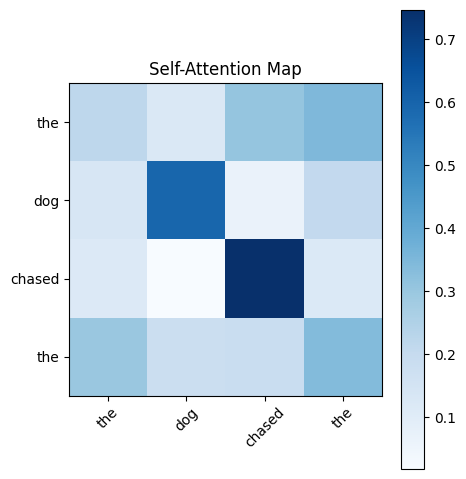

In [20]:
# 1. Select a sample input from your training data
ex_ix = 0  # or any valid index into your windowed input dataset
input_ids = inputs[ex_ix]                          # e.g., [2, 3, 4, 2]
tokens = [idx2word[i] for i in input_ids]          # Human-readable tokens

model.eval()
x_example = torch.tensor([input_ids], dtype=torch.long)  # [batch, seq]

with torch.no_grad():
    logits, attn_weights = model(x_example)

# 3. Plot attention map before OR after training
plot_attention(attn_weights, tokens, title="Self-Attention Map")

### 2.4 The Training Loop

Now that you have your model, data, and attention visualization tools ready, it’s time to train your model!  
You’ll use a classic PyTorch training loop that:

- Batches your data for efficient processing,
- Runs each batch through the model,
- Uses the loss function to measure how well your model predicts the next word,
- Updates the model parameters using the Adam optimizer,
- And tracks your progress using a live progress bar.

As the epochs progress, you should see the average loss drop—evidence that your model is learning to predict the next word given context!

In [21]:
def train_model(model, loader, loss_fn, optimizer, epochs=20, device='cpu'):
    """
    Executes the training loop for a given model over a specified number of epochs.

    Args:
        model: The neural network model to be trained.
        loader: The DataLoader providing batches of training data.
        loss_fn: The criterion used to calculate the model error.
        optimizer: The optimization algorithm used to update model weights.
        epochs: The total number of complete passes through the training dataset.
        device: The hardware device (e.g., 'cpu' or 'cuda') to perform computations on.

    Returns:
        None. This function performs in-place updates to the model weights.
    """
    # Transfer the model parameters to the specified computation device
    model.to(device)
    # Iterate through the training process for the defined number of epochs
    for epoch in range(epochs):
        # Configure the model for training mode
        model.train()
        # Initialize an accumulator for the total loss across the epoch
        total_loss = 0
        # Iterate through the data batches with a progress bar visualization
        with tqdm(loader, desc=f"Epoch {epoch+1}/{epochs}") as pbar:
            for xb, yb in pbar:
                # Move the input and target tensors to the active device
                xb, yb = xb.to(device), yb.to(device)
                # Reset the gradients of all optimized parameters
                optimizer.zero_grad()
                # Execute the forward pass to obtain prediction logits
                logits, _ = model(xb)
                # Calculate the difference between predictions and ground truth labels
                loss = loss_fn(logits, yb)
                # Perform backpropagation to compute gradients for the current batch
                loss.backward()
                # Apply the gradients to update the model parameters
                optimizer.step()
                # Sum the loss for the batch weighted by the batch size
                total_loss += loss.item() * xb.size(0)
                # Update the progress bar with the current batch loss
                pbar.set_postfix(loss=loss.item())
        # Compute the mean loss over the entire dataset for the current epoch
        avg_loss = total_loss / len(loader.dataset)
        # Output the performance summary for the completed epoch
        print(f"Epoch {epoch+1}: avg loss = {avg_loss:.4f}")

In [22]:
# Example usage:
optimizer = optim.Adam(model.parameters(), lr=0.01)     # Adam is a popular optimizer for NLP
loss_fn = nn.CrossEntropyLoss()                         # Classic loss for next-token prediction

# Assume 'loader' is your DataLoader for (input_window, target_next_token) pairs,
# and 'device' is set to "cuda" if available, else "cpu"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_model(model, loader, loss_fn, optimizer, epochs=25, device=device)

Epoch 1/25:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 1: avg loss = 2.3780


Epoch 2/25:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 2: avg loss = 2.2094


Epoch 3/25:   0%|          | 0/1 [00:00<?, ?it/s]

...

Epoch 23: avg loss = 0.6078


Epoch 24/25:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 24: avg loss = 0.5706


Epoch 25/25:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 25: avg loss = 0.5258


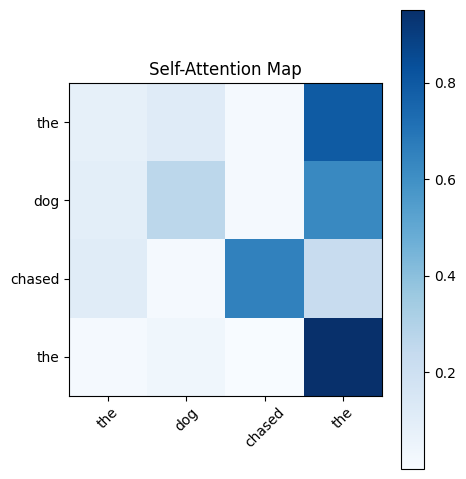

In [23]:
# 1. Select a sample input from your training data
ex_ix = 0  # or any valid index into your windowed input dataset
input_ids = inputs[ex_ix]                          # e.g., [2, 3, 4, 2]
tokens = [idx2word[i] for i in input_ids]          # Human-readable tokens

model.eval()
x_example = torch.tensor([input_ids], dtype=torch.long, device = device)  # [batch, seq]

with torch.no_grad():
    logits, attn_weights = model(x_example)

# 3. Plot attention map before OR after training
plot_attention(attn_weights, tokens, title="Self-Attention Map")

In the input sequence—"the dog chased the"—the model starts by assigning relatively even attention to all tokens, meaning each word's new representation is influenced by almost all other words. This is shown in the first (before training) map, where each row has smoothly distributed blues, and no single cell stands out.

However, after training, the map changes dramatically: you see much darker squares in particular positions of each row. For example, the first "the" might now strongly attend to "dog" while "dog" might heavily attend to "chased" and so on. What this means is that the model has learned, through exposure to many sentence patterns, that certain words in this context are especially important for predicting or understanding others. 

In practical terms:  
- When the model processes "the" it recognizes from training that "dog" is the most relevant context in this position—perhaps because "the dog" is a frequent phrase structure.
- When it processes "dog" it attends more strongly to "chased" learning that verbs often follow nouns in your data.
- The strong attention from the last "the" to "dog" (or "chased" depending on weights) reflects the model's understanding of typical sentence continuations in this specific dataset.

So, this focused attention after training visually confirms that the self-attention mechanism has picked up on real relationships in your sentence structure, allowing the model to make smarter predictions by leveraging learned language patterns, not just treating all words equally.

### 2.5 Predicting Multiple Next Words

After training, you want to see your model in action—not just on a single token, but generating entire continuations from a given prompt.

The function below takes a starting sentence, uses your tokenizer to split it into tokens, and then generates as many new words as you want, one at a time. Each prediction uses the most recent `seq_len` words as context, just like during training. The function maps between words and token IDs using your vocabulary.

This allows you to explore how your self-attention model “writes” language, step by step!

In [24]:
def generate_next_words(model, sentence, tokenizer, word2idx, idx2word, max_tokens=5, seq_len=4, device='cpu'):
    """
    Predicts and appends subsequent tokens to a given input sequence using a trained model.

    Args:
        model: The trained neural network used for prediction.
        sentence: The initial input string to start generation from.
        tokenizer: A callable object used to convert strings into tokens.
        word2idx: A dictionary mapping token strings to their respective integer indices.
        idx2word: A dictionary mapping integer indices back to their token strings.
        max_tokens: The total number of new tokens to be generated.
        seq_len: The fixed context window size required by the model.
        device: The hardware device ('cpu' or 'cuda') to perform inference on.

    Returns:
        generated: A list of strings containing the original tokens plus the newly predicted tokens.
    """
    # Set the model to evaluation mode to disable training-specific behaviors like dropout
    model.eval()
    # Convert the raw input sentence into a list of individual tokens
    generated = tokenizer(sentence)

    # Iteratively predict the next token for the specified number of steps
    for _ in range(max_tokens):
        # Extract the most recent tokens to fit the model's context length, padding if necessary
        window = generated[-seq_len:] if len(generated) >= seq_len \
                 else ['<pad>'] * (seq_len - len(generated)) + generated

        # Map window tokens to indices, using the unknown token marker for missing words
        input_ids = torch.tensor([[word2idx.get(w, word2idx['<unk>']) for w in window]], dtype=torch.long).to(device)

        # Disable gradient calculation to save memory and compute during inference
        with torch.no_grad():
            # Perform a forward pass to obtain prediction logits
            logits, _ = model(input_ids)
            # Select the token index with the highest predicted probability
            next_id = logits.argmax(dim=-1).item()

        # Retrieve the string representation of the predicted token index
        next_word = idx2word[next_id]
        # Append the new word to the sequence for the next iteration of context
        generated.append(next_word)

    # Provide the full list of tokens including the generated sequence
    return generated

In [25]:
# Example usage:
sentence = "the dog chased the"
output = generate_next_words(model, sentence, tokenizer, word2idx, idx2word, max_tokens=1, seq_len=SEQ_LEN, device=device)
print("Generated sequence:", " ".join(output))

Generated sequence: the dog chased the cat


## 3 - To Train, or Not to Train: A Shakespeare Generator Example

Now you’ll put all the pieces together for a real application:  
a mini “Shakespeare Generator” trained on actual lines from the Bard’s plays.

In this section, you’ll apply your attention-based model to generate new Shakespearean text.  
You'll use the tools and code you built above to:

- Prepare and encode the Shakespeare dataset
- Train your self-attention model on it
- Generate new lines of “Shakespeare” by predicting multiple words from a chosen prompt

Let’s see how your custom transformer becomes a playwright!

### 3.1 Data Preparation

To train your model on real Shakespearean language, you first need to get the dataset and inspect its format. In this step, you’ll automatically download a classic, open-source collection of Shakespeare’s works if it’s not already present. You’ll also peek at the start of the file to understand the kind of text you’re working with.

This raw text will form the basis for all your training and generation experiments.

In [26]:
# Download if needed
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
filename = "shakespeare.txt"

# Check if file already exists
if os.path.exists(filename):
    print(f"'{filename}' already exists, skipping download.\n")
else:
    print(f"Downloading '{filename}'...")
    urllib.request.urlretrieve(url, filename)
    print(f"Download complete!\n")

# Read the text
with open(filename, "r", encoding="utf-8") as f:
    text = f.read()

print(text[:300])  # Just peek at the start

'shakespeare.txt' already exists, skipping download.

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us


Next, you’ll need to split Shakespeare’s text into tokens so your model can process it.  
This custom tokenizer is designed to:

- Replace every line break (`\n`) with a special `<nl>` token, so your model can learn line boundaries or poetic structure if needed.
- Split the text into words (including contractions), standalone punctuation marks, and `<nl>` as individual tokens.

This approach gives your model clear, structured input ready for building a vocabulary and training.

In [27]:
class ShakespeareTokenizer:
    """
    A specialized tokenizer designed for processing theatrical or poetic text.
    """
    def __call__(self, text):
        """
        Processes the input text into a specific list of tokens.

        Args:
            text: The raw string to be tokenized.

        Returns:
            A list of strings containing words, contractions, special line 
            break tokens, and punctuation marks.
        """
        # Substitute newline characters with a identifiable string token
        text = text.replace('\n', ' <nl> ')
        # Extract word characters, possessives, special tokens, and symbols using regex
        return re.findall(r"\w+(?:'\w+)?|<nl>|[^\w\s]", text)

In [28]:
# Instantiate your tokenizer
tokenizer = ShakespeareTokenizer()

# Build vocabulary from all Shakespeare lines using your tokenizer
vocab, word2idx, idx2word = build_vocab([text], tokenizer, min_freq=1)
print("Vocab size:", len(vocab))
print("First 20 vocab words:", vocab[:20])

Vocab size: 14300
First 20 vocab words: ['<pad>', '<unk>', 'First', 'Citizen', ':', '<nl>', 'Before', 'we', 'proceed', 'any', 'further', ',', 'hear', 'me', 'speak', '.', 'All', 'Speak', 'You', 'are']


To prepare your data for training, you need to break up the full Shakespeare text into many (input, target) pairs using a **sliding window** approach:

- Each input consists of a sequence of `SEQ_LEN` consecutive tokens.
- The target is the immediate next token that follows this window in the text.

By sliding this window over the entire dataset, you create thousands of training pairs that help your model learn the flow and structure of real language—even across line breaks and scene changes.

Below, you’ll build these pairs and print out an example to see exactly what your model will use as context and what it's being trained to predict.

In [29]:
SEQ_LEN = 25
tokens = tokenizer(text)    # Tokenize the full text as one sequence!
inputs = []
targets = []
for i in range(len(tokens) - SEQ_LEN):
    window = tokens[i:i+SEQ_LEN]
    target = tokens[i+SEQ_LEN]
    input_ids = [word2idx.get(w, word2idx['<unk>']) for w in window]
    target_id = word2idx.get(target, word2idx['<unk>'])
    inputs.append(input_ids)
    targets.append(target_id)
        
print("Number of (input, target) pairs:", len(inputs))
print("Example input:", [idx2word[i] for i in inputs[0]])
print("Example target:", idx2word[targets[0]])

Number of (input, target) pairs: 293574
Example input: ['First', 'Citizen', ':', '<nl>', 'Before', 'we', 'proceed', 'any', 'further', ',', 'hear', 'me', 'speak', '.', '<nl>', '<nl>', 'All', ':', '<nl>', 'Speak', ',', 'speak', '.', '<nl>', '<nl>']
Example target: First


### 3.2 Building The Dataset

With your `(input, target)` pairs ready, you now need to convert them into a format that's easy for PyTorch to use during training.

By defining a custom `ShakespeareDataset`, you make sure each example is quickly and reliably available by index, allowing PyTorch's `DataLoader` to:
- batch sequences together,
- shuffle the training data,
- and prepare everything for efficient model training.

This setup is not only standard for PyTorch workflows, but also makes scaling up to bigger datasets or experiments much easier.

In [30]:
class ShakespeareDataset(Dataset):
    """
    A dataset class for handling tokenized text sequences and their corresponding targets.

    Args:
        inputs: A list or array of sequence windows representing the input data.
        targets: A list or array of labels or next-word indices corresponding to the inputs.
    """
    def __init__(self, inputs, targets):
        """
        Initializes the dataset by converting input and target data into tensors.

        Args:
            inputs: The raw input sequences.
            targets: The ground truth labels for the sequences.
        """
        # Maintain inputs and targets as long tensors to ensure compatibility with embedding layers
        self.inputs = torch.tensor(inputs, dtype=torch.long)
        # Store the target labels as long tensors for use in loss calculation
        self.targets = torch.tensor(targets, dtype=torch.long)

    def __len__(self):
        """
        Calculates the total size of the dataset.

        Returns:
            The total number of samples available in the dataset.
        """
        # Return the count of samples based on the length of the input tensor
        return len(self.inputs)

    def __getitem__(self, idx):
        """
        Retrieves a single input-target pair by its index.

        Args:
            idx: The integer index of the data point to retrieve.

        Returns:
            input_sample: The tensor representing the input window at the given index.
            target_sample: The tensor representing the target label at the given index.
        """
        # Provide the input sequence and its associated target as a tuple
        return self.inputs[idx], self.targets[idx]

In [31]:
dataset = ShakespeareDataset(inputs, targets)
loader = DataLoader(dataset, batch_size=128, shuffle=True, num_workers=0)
vocab_size = len(vocab)  # Store vocab size for easy reference

### 3.3 PyTorch Multihead Attention

Up to this point, you've manually implemented every piece of self-attention, giving you a deep, hands-on understanding of how it works. Now, you'll take the next step towards building state-of-the-art models: using PyTorch's built-in `nn.MultiheadAttention` layer.

Why use the built-in layer instead of your manual version?
- **Efficiency:** PyTorch's implementation is highly optimized and leveraged in real production models.
- **Complexity:** The built-in module supports multi-head attention out of the box, allowing your model to learn multiple types of linguistic relationships in parallel—something that gets cumbersome to code by hand.
- **Scalability:** You can easily adjust the number of heads, dropout, or embedding size, and take advantage of GPU acceleration and batched computation.
- **Compatibility:** This layer is the exact one used in modern transformers, making it easy to transition your knowledge and code to larger or more sophisticated projects.

<details>
<summary><b>How Attention Works (Formula Explanation)</b></summary>

Self-attention for a sequence is computed as:

$$
\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^\top}{\sqrt{d_k}}\right) V
$$

Where:

- $Q = X W^Q$ are the query vectors,
- $K = X W^K$ are the key vectors,
- $V = X W^V$ are the value vectors,
- $X$ is the input matrix (sequence of embeddings),
- $W^Q, W^K, W^V$ are the learned projection matrices,
- $d_k$ is the dimension of the key/query,
- The output is a weighted sum of the value vectors, with weights determined by the similarity (dot product) between queries and keys.

For multi-head attention, you concatenate several such outputs (with parallel projections), and then linearly project again to the original embedding size.

</details>


Below, you'll see how easy it is to swap out your custom self-attention for PyTorch’s flexible, production-level multi-head attention layer.

In [32]:
class SelfAttnWithMHA(nn.Module):
    """
    A sequence modeling architecture using multi-head attention and positional embeddings.

    Args:
        vocab_size: The total number of unique tokens in the vocabulary.
        seq_len: The fixed length of input sequences.
        embed_dim: The dimensionality of the hidden states and embeddings.
        num_heads: The number of parallel attention heads.
        dropout: The dropout probability applied to the attention weights.
    """
    def __init__(self, vocab_size, seq_len, embed_dim=768, num_heads=12, dropout=0.1):
        """
        Initializes the model layers and internal configurations.

        Args:
            vocab_size: Size of the vocabulary.
            seq_len: Maximum sequence length.
            embed_dim: Dimensionality of the embedding space.
            num_heads: Number of attention heads.
            dropout: Regularization dropout rate.
        """
        super().__init__()
        # Layer to map token indices to continuous vector representations
        self.tok_embed = nn.Embedding(vocab_size, embed_dim)
        # Layer to provide order information to the model via learnable vectors
        self.pos_embed = nn.Embedding(seq_len, embed_dim)
        # Multi-head attention mechanism for capturing complex sequence dependencies
        self.attn = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        # Projection layer to transform contextual representations into vocabulary logits
        self.fc = nn.Linear(embed_dim, vocab_size)

    def forward(self, token_ids):
        """
        Performs a forward pass on a batch of token sequences.

        Args:
            token_ids: A tensor of token indices with shape [batch_size, seq_len].

        Returns:
            logits: Prediction scores for the next token based on the final hidden state.
            attn_w: The computed attention weights representing token relationships.
        """
        batch_size, seq_len = token_ids.shape
        # Create a range of indices to represent the relative position of each token
        positions = torch.arange(seq_len, device=token_ids.device).unsqueeze(0).expand(batch_size, seq_len)
        # Combine token-specific and position-specific embeddings
        input_vecs = self.tok_embed(token_ids) + self.pos_embed(positions)
        # Calculate contextual representations and attention scores across all heads
        attn_out, attn_w = self.attn(input_vecs, input_vecs, input_vecs, need_weights=True)
        # Isolate the hidden state of the final token in the sequence
        last_hidden = attn_out[:, -1, :]
        # Generate the final output scores over the vocabulary
        logits = self.fc(last_hidden)
        # Provide the prediction results along with the attention weight matrix
        return logits, attn_w

In [33]:
model = SelfAttnWithMHA(vocab_size=vocab_size, seq_len=SEQ_LEN)
# Create a new instance of your (multi-head attention) model, sized to your vocab and sequence length

loss_fn = nn.CrossEntropyLoss()  
# Define the loss function (CrossEntropy is standard for language modeling);
# Redefine here to ensure it's fresh and configured for your current task

optimizer = optim.Adam(model.parameters(), lr=0.001)
# Define the optimizer (Adam adjusts model parameters during training);
# Always recreate the optimizer after making a new model, or when model params change

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  
# Select GPU ("cuda") if available, otherwise use CPU

model.to(device)
# Move your model’s parameters to the chosen device (CPU or GPU)

torch.cuda.empty_cache()
# (Optional) Clear unused memory from the GPU to avoid memory leaks or OOM errors;
# Especially useful if you ran a different model before in the same session

In [34]:
# Example usage:
sentence = "to be or not"
output = generate_next_words(model, sentence, tokenizer, word2idx, idx2word, max_tokens=50, seq_len=SEQ_LEN, device=device)
print("Generated sequence:", " ".join(output))

Generated sequence: to be or not palmer's palmer's palmer's forgot splinter'd deliverance splinter'd splinter'd splinter'd splinter'd confess confess confess confess deniest Canker'd deniest be splinter'd Best believe Pygmalion's afore Watchman Nestor whereupon Call drag Rice Call Conspirators Conspirators Call intelligencing encouragement extirp merits unsheathe appointments Half Offended Call ha't forefend pile ghostly appointments heaven's lions Half


### 3.4 Training Your Attention Model

Now you’re ready to train your multi-head attention language model!  
This function wraps the entire training process: it takes batches from your DataLoader, computes the model’s predictions, compares them to the true next words using the loss function, and updates the model’s parameters using the optimizer.  
You’ll see a progress bar for each epoch, along with average loss—which should go down as your model learns from the data.

Run the cell below to begin training. You can increase the number of epochs to achieve better performance, but keep in mind that this will also increase the training time.

In [35]:
def train_model(model, loader, loss_fn, optimizer, epochs=10, device='cpu', vocab_size=None):
    """
    Executes the training loop for a sequence model over a specified number of epochs.

    Args:
        model: The neural network model to be trained.
        loader: The DataLoader instance providing batches of training data.
        loss_fn: The loss function used to evaluate model performance.
        optimizer: The optimization algorithm used to update model weights.
        epochs: The total number of iterations over the complete dataset.
        device: The target hardware for computation (e.g., 'cpu' or 'cuda').
        vocab_size: Optional parameter specifying the size of the vocabulary.

    Returns:
        None. This function modifies the model and optimizer states in-place.
    """
    # Transfer the model to the specified hardware device
    model.to(device)
    # Begin iterating through the specified number of training cycles
    for epoch in range(epochs):
        # Configure the model for training mode to enable specific behaviors like dropout
        model.train()
        # Initialize an accumulator for the cumulative loss within the epoch
        total_loss = 0
        # Determine the total number of batches in the data loader
        n_batches = len(loader)
        # Iterate through data batches using a progress bar for monitoring
        with tqdm(loader, desc=f"Epoch {epoch+1}/{epochs}") as pbar:
            for xb, yb in pbar:
                # Move the input and target tensors to the active device
                xb, yb = xb.to(device), yb.to(device)
                # Reset gradients of the model parameters to zero
                optimizer.zero_grad()
                # Perform the forward pass to obtain logits and attention weights
                logits, _ = model(xb)
                # Calculate the loss based on model predictions and actual targets
                loss = loss_fn(logits, yb)
                # Execute the backward pass to calculate gradients
                loss.backward()
                # Update model parameters based on the computed gradients
                optimizer.step()
                # Accumulate the weighted loss for the current batch
                total_loss += loss.item() * xb.size(0)
                # Display the loss value for the current batch in the progress bar
                pbar.set_postfix(loss=loss.item())

        # Calculate the mean loss across all samples in the dataset
        avg_loss = total_loss / len(loader.dataset)
        # Log the performance summary for the completed epoch
        print(f"Epoch {epoch+1:2d}: avg loss = {avg_loss:.4f}")

In [36]:
# Usage:
EPOCHS = 5
vocab_size = len(vocab)  # Pass this in!
train_model(model, loader, loss_fn, optimizer, epochs=EPOCHS, device=device, vocab_size=vocab_size)

Epoch 1/5:   0%|          | 0/2294 [00:00<?, ?it/s]

Epoch  1: avg loss = 5.6564


Epoch 2/5:   0%|          | 0/2294 [00:00<?, ?it/s]

Epoch  2: avg loss = 5.0157


Epoch 3/5:   0%|          | 0/2294 [00:00<?, ?it/s]

Epoch  3: avg loss = 4.4627


Epoch 4/5:   0%|          | 0/2294 [00:00<?, ?it/s]

Epoch  4: avg loss = 3.9058


Epoch 5/5:   0%|          | 0/2294 [00:00<?, ?it/s]

Epoch  5: avg loss = 3.6843


When you trained your model, you used a special token `<nl>` to represent newlines (line breaks) in the Shakespeare dataset.  
This allowed your tokenizer and model to recognize and generate line boundaries just like any other word.

However, when you actually want to read or display the generated text, you want to see real line breaks—not the literal string `<nl>`.  
That's why, in the generation function, you replace every occurrence of `<nl>` with the actual newline character `\n`.  
This makes your generated samples readable and visually closer to real Shakespearean poetry or drama!

In other words:  
- **Inside the model:** `<nl>` acts as a "word" that teaches your network where lines start and end.  
- **Outside the model:** you convert `<nl>` back to a true line break so your output looks natural.

This small transformation turns a list like  
`["to", "be", "<nl>", "or", "not", "<nl>", "to", "be"]`  
into something that prints as  
```
to be
or not
to be
```

In [37]:
# A helper class to generate next words from a model with temperature sampling.

class NextWordGenerator:
    """
    Generate next tokens from a language model using a fixed context window and temperature sampling.

    Uses left-padding with a padding token to fill the initial context window.
    Applies temperature scaling to logits, then samples with multinomial.
    Converts special newline tokens to standard newline characters in the final output.
    """

    def __init__(
        self,
        model,
        tokenizer,
        word2idx,
        idx2word,
        *,
        seq_len=6,
        device="cpu",
        pad_token="<pad>",
        unk_token="<unk>",
        nl_token="<nl>",
    ):
        """
        Initialize the NextWordGenerator instance.

        Arguments:
        model: The neural network model used for sequence generation.
        tokenizer: A callable function that converts a string into a sequence of string tokens.
        word2idx: A dictionary mapping string tokens to their integer indices.
        idx2word: A dictionary mapping integer indices back to string tokens.
        seq_len: The maximum number of tokens to keep in the context window.
        device: The hardware device where tensors will be allocated.
        pad_token: The string representation of the padding token.
        unk_token: The string representation of the unknown token.
        nl_token: The string representation of the newline token.
        """
        # Assign the model to the instance variables
        self.model = model
        # Store the tokenizer function
        self.tokenizer = tokenizer
        # Store the mapping from words to indices
        self.word2idx = word2idx
        # Store the mapping from indices to words
        self.idx2word = idx2word
        # Define the context window length
        self.seq_len = seq_len
        # Define the processing device
        self.device = device
        # Define the token used for sequence padding
        self.pad_token = pad_token
        # Define the token used for unknown words
        self.unk_token = unk_token
        # Define the token representing a newline
        self.nl_token = nl_token

        # Cache the integer ID for the unknown token to prevent repeated dictionary lookups
        self._unk_id = self.word2idx[self.unk_token]

    def _make_window(self, generated):
        """
        Create a fixed-size context window from the generated tokens.

        Arguments:
        generated: A list of string tokens that have been generated so far.

        Returns:
        A list of string tokens representing the padded or truncated context window.
        """
        # Check if the generated sequence has reached or exceeded the maximum sequence length
        if len(generated) >= self.seq_len:
            # Slice and return only the most recent tokens up to the allowed sequence length
            return generated[-self.seq_len:]
        # Calculate the deficit of tokens needed to fill the required sequence window
        pad_count = self.seq_len - len(generated)
        # Prepend the necessary amount of padding tokens to the sequence
        return [self.pad_token] * pad_count + generated

    def _encode(self, tokens):
        """
        Convert a sequence of string tokens into a tensor of corresponding integer indices.

        Arguments:
        tokens: A sequence of string tokens to be encoded.

        Returns:
        A tensor containing the encoded token indices.
        """
        # Look up the index for each token, defaulting to the unknown token ID if not found
        ids = [self.word2idx.get(t, self._unk_id) for t in tokens]
        # Construct and return a tensor of the indices on the specified processing device
        return torch.tensor([ids], dtype=torch.long, device=self.device)

    def _decode_id(self, idx):
        """
        Convert a numerical token index back into its string representation.

        Arguments:
        idx: The integer index representing a specific token.

        Returns:
        The string representation of the token corresponding to the given index.
        """
        # Retrieve and return the string mapped to the specified index
        return self.idx2word[idx]

    def _postprocess(self, tokens):
        """
        Process the generated sequence of tokens to correctly format special characters.

        Arguments:
        tokens: A list of generated string tokens.

        Returns:
        A list of string tokens where special formatting tokens have been replaced.
        """
        # Replace custom newline tokens with actual newline characters for display or printing
        return [("\n" if t == self.nl_token else t) for t in tokens]

    def generate(self, sentence, *, max_tokens=20, temperature=1.0):
        """
        Generate a sequence of tokens continuing from the provided input sentence.

        Arguments:
        sentence: The initial string text to begin generation from.
        max_tokens: The maximum limit of new tokens to generate.
        temperature: A float value used to scale the logits before probability sampling.

        Returns:
        A list of string tokens containing the full generated sequence including the original tokens.
        """
        # Verify that the temperature parameter is strictly greater than zero
        if temperature <= 0:
            # Raise an exception if an invalid temperature value is provided
            raise ValueError("temperature must be > 0")

        # Switch the model to evaluation mode to ensure consistent generation behavior
        self.model.eval()
        # Tokenize the initial sentence into a list, preparing to mutate it in place without copying
        generated = list(self.tokenizer(sentence))

        # Temporarily disable gradient tracking to reduce memory usage during generation
        with torch.no_grad():
            # Loop over the allowed maximum number of tokens to generate
            for _ in range(max_tokens):
                # Retrieve the properly sized and padded context window for the current step
                window = self._make_window(generated)
                # Encode the context window tokens into a tensor of IDs
                input_ids = self._encode(window)

                # Feed the input tensor to the model to get raw logits, expecting a shape of [1, vocab]
                logits, _ = self.model(input_ids)
                # Scale the raw logits using the defined temperature variable
                logits = logits / temperature
                # Apply the softmax function to convert scaled logits into a probability distribution
                probs = torch.softmax(logits, dim=-1)

                # Sample the next token index based on the calculated probabilities, returning shape [1, 1]
                next_id = torch.multinomial(probs, num_samples=1).item()
                # Decode the chosen numeric index back into a string token
                next_token = self._decode_id(next_id)
                # Append the newly generated token to the sequence list
                generated.append(next_token)

        # Apply post-processing to the sequence and return the final list of tokens
        return self._postprocess(generated)

In [38]:
# Example usage:
generator = NextWordGenerator(
    model=model,
    tokenizer=tokenizer,
    word2idx=word2idx,
    idx2word=idx2word,
    seq_len=SEQ_LEN,
    device=device,
)

output = generator.generate("To be or not to", max_tokens=50, temperature=1.0)
print("Generated sequence:", " ".join(output))

Generated sequence: To be or not to die Claudio 
 dog was Comes to ask my castle shall ? 
 
 PARIS become 
 This precious submission foot your meat . 
 
 COMINIUS : 
 I it out : alas ! show I no son ! 
 Come monstrous , ones queen be choleric : 



## 4 - Conclusion

In this lab, you’ve worked through every step of building a modern attention-based language model from scratch:
- You started by preparing your text data, creating a vocabulary, and organizing your dataset using sliding windows.
- You implemented self-attention both manually and using PyTorch’s powerful `nn.MultiheadAttention` layer, learning exactly how these models “pay attention” to context.
- You trained your model on real Shakespearean language, and were able to generate new text—sometimes even capturing the style and rhythm of the Bard himself!

By working hands-on with both custom and built-in attention, you gained a deep understanding of what makes transformers so effective in modern NLP:
- The ability to learn flexible, context-dependent relationships within text;
- The scalability and practicality of using optimized library components;
- The importance of good data preparation and robust, interpretable generation.

Keep exploring! Try different seeds, experiment with model hyperparameters, or dive deeper into visualizing attention maps.  